In [9]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from glob import glob
import IPython.display as ipd
from tqdm.notebook import tqdm
import subprocess

In [10]:
input_file = "Crowd-Activity-All (1).avi"
subprocess.run([
    'ffmpeg',
    '-i', input_file,
    '-qscale', '0',
    'Crowd-Activity-All.mp4'
])

CompletedProcess(args=['ffmpeg', '-i', 'Crowd-Activity-All (1).avi', '-qscale', '0', 'Crowd-Activity-All.mp4'], returncode=0)

In [11]:
!dir /A

 Volume in drive C is OS
 Volume Serial Number is 8A56-827F

 Directory of C:\crowd dataset

09-01-2026  15:47    <DIR>          .
08-01-2026  20:50    <DIR>          ..
09-01-2026  00:07    <DIR>          .ipynb_checkpoints
09-01-2026  14:53    <DIR>          .virtual_documents
09-01-2026  00:06    <DIR>          anaconda_projects
08-01-2026  20:07        24,821,310 Crowd-Activity-All (1).avi
09-01-2026  00:52        11,140,427 Crowd-Activity-All.mp4
09-01-2026  15:47            11,423 crowd_anomaly.ipynb
               3 File(s)     35,973,160 bytes
               5 Dir(s)  667,393,617,920 bytes free


In [12]:
ipd.Video('Crowd-Activity-All.mp4', width = 700)

In [13]:
# Load video in capture
cap = cv2.VideoCapture('Crowd-Activity-All.mp4')

In [14]:
cap.get(cv2.CAP_PROP_FRAME_COUNT)

7739.0

In [15]:
height = cap.get(cv2.CAP_PROP_FRAME_HEIGHT)
width = cap.get(cv2.CAP_PROP_FRAME_WIDTH)
print(f"height is {height}, width is {width}")

height is 240.0, width is 320.0


In [16]:
fps = cap.get(cv2.CAP_PROP_FPS)
print(f"fps is {fps:0.2f}")

fps is 30.00


In [17]:
cap.release()

In [18]:
cap = cv2.VideoCapture('Crowd-Activity-All.mp4')
ret, img = cap.read()
print(f'Returned {ret} and img of shape {img.shape}')

Returned True and img of shape (240, 320, 3)


In [19]:
def display_cv2_img(img, figsize=(10, 10)):
    img_= cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(img_)
    ax.axis('off')

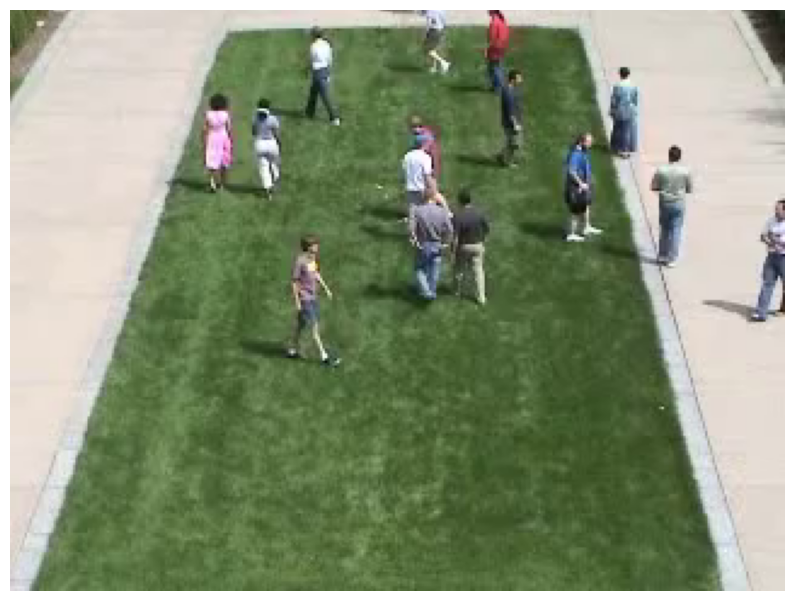

In [20]:
display_cv2_img(img)

In [21]:
cap.release()

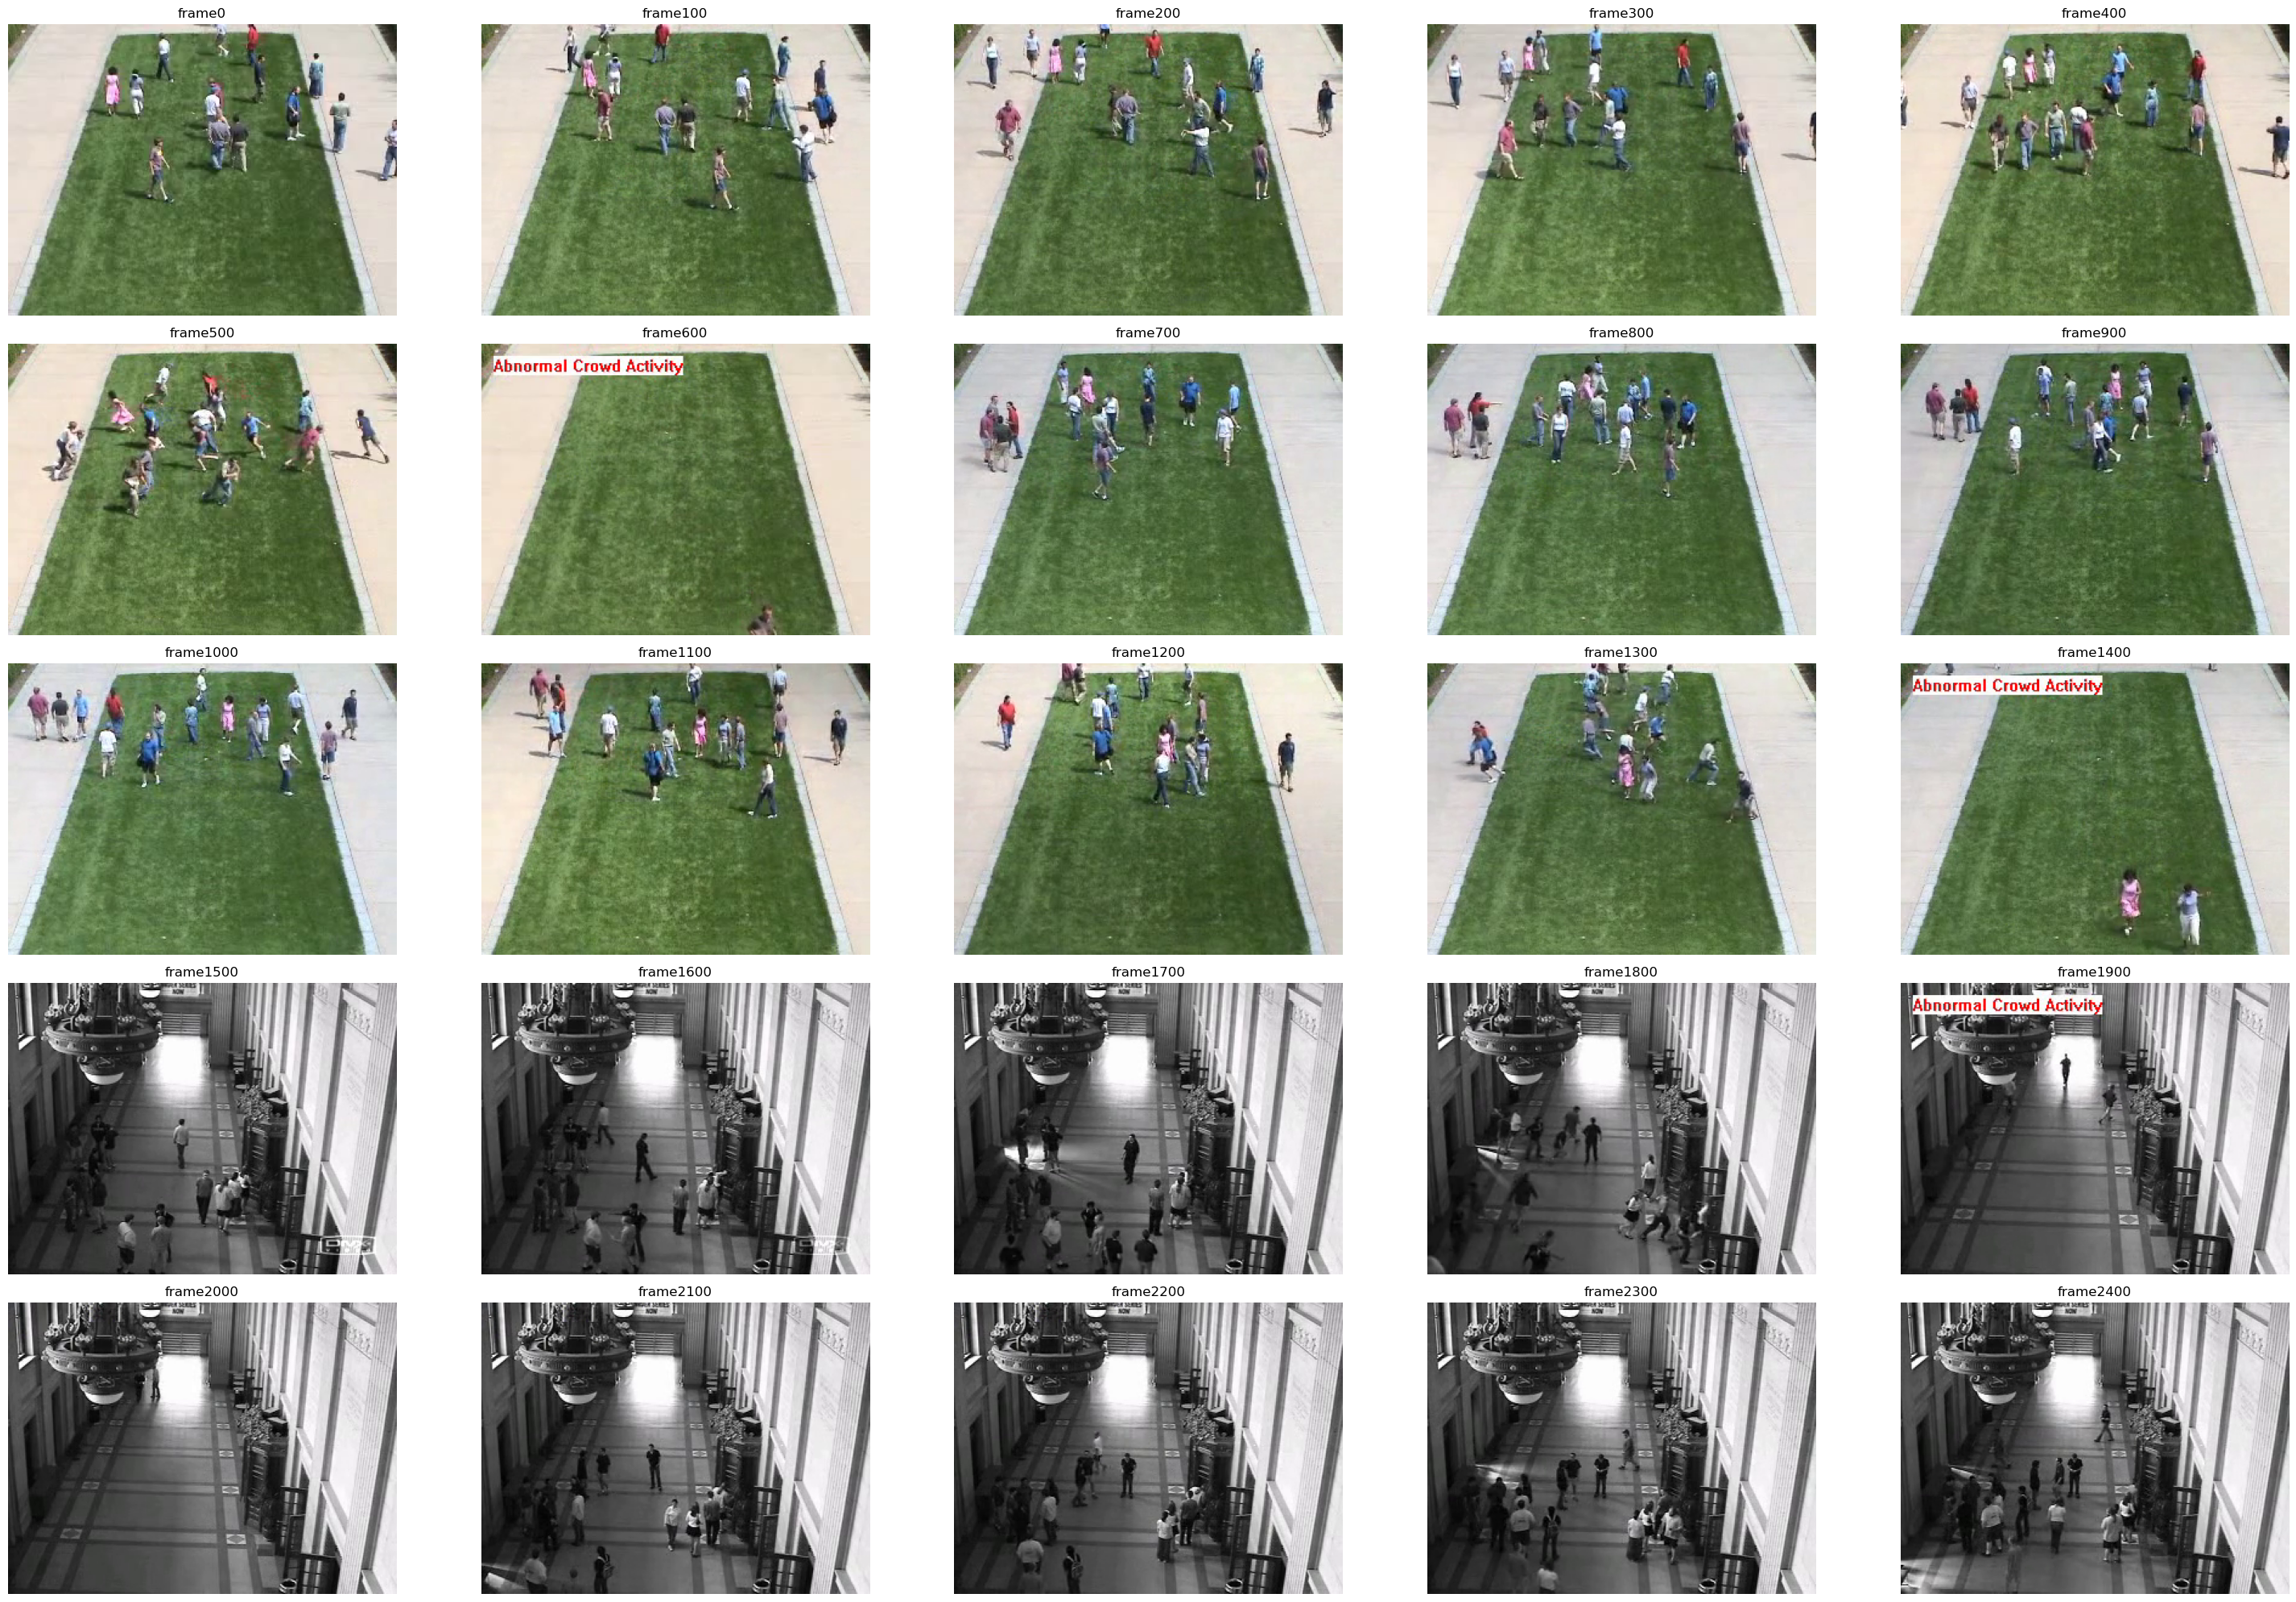

In [22]:
fig, axs = plt.subplots(5, 5, figsize=(30, 20))
axs = axs.flatten()
cap = cv2.VideoCapture('Crowd-Activity-All.mp4')
n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

img_idx = 0
for frame in range(n_frames):
    ret, img = cap.read()
    if ret == False:
        break
    if frame % 100 == 0:
        # Check if we've reached the limit of our subplot grid
        if img_idx >= len(axs):
            break  # Stop adding images if we've filled all subplots
        axs[img_idx].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        axs[img_idx].set_title(f'frame{frame}')
        axs[img_idx].axis('off')
        img_idx += 1 

plt.tight_layout()
plt.show()

cap.release()

In [23]:
subprocess.run([
    "ffmpeg",
    "-i", "Crowd-Activity-All.mp4",
    "-vf", "fps=15",
    "crowd_15fps.mp4"
], check=True)

CompletedProcess(args=['ffmpeg', '-i', 'Crowd-Activity-All.mp4', '-vf', 'fps=15', 'crowd_15fps.mp4'], returncode=0)

In [30]:
cap2 = cv2.VideoCapture('crowd_15fps.mp4')
print(f'The total no. of frames after normalization is now {cap2.get(cv2.CAP_PROP_FRAME_COUNT)} and the fps is {cap2.get(cv2.CAP_PROP_FPS)}')

The total no. of frames after normalization is now 3870.0 and the fps is 15.0
